In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from sklearn.cluster import KMeans

### Robot Sample Locations

In [14]:
# Build robot data table 
ranges = pd.read_csv('range.csv')
locations = pd.read_csv('robot_locations.csv')

robots = (
    locations.merge(ranges, on='index', how='inner')
    .rename(columns={'index': 'robot_id'})
    [['robot_id', 'longitude', 'latitude', 'range']]
    .sort_values('robot_id')
    .reset_index(drop=True)
)

#robots.to_csv('robot_table.csv', index=False)
robots.head()

,robot_id,longitude,latitude,range
0,0,-120.240815,-79.238374,127.868274
1,1,-134.537839,-83.426214,87.246488
2,2,-105.282215,-84.681705,64.393799
3,3,-105.453243,-77.964007,100.815352
4,4,-168.816260,-86.934888,36.021544


Number of robots: 1072
Longitude range: -179.589 to 179.986
Latitude range: -89.992 to -63.988
Robot range: 10.743 to 173.899


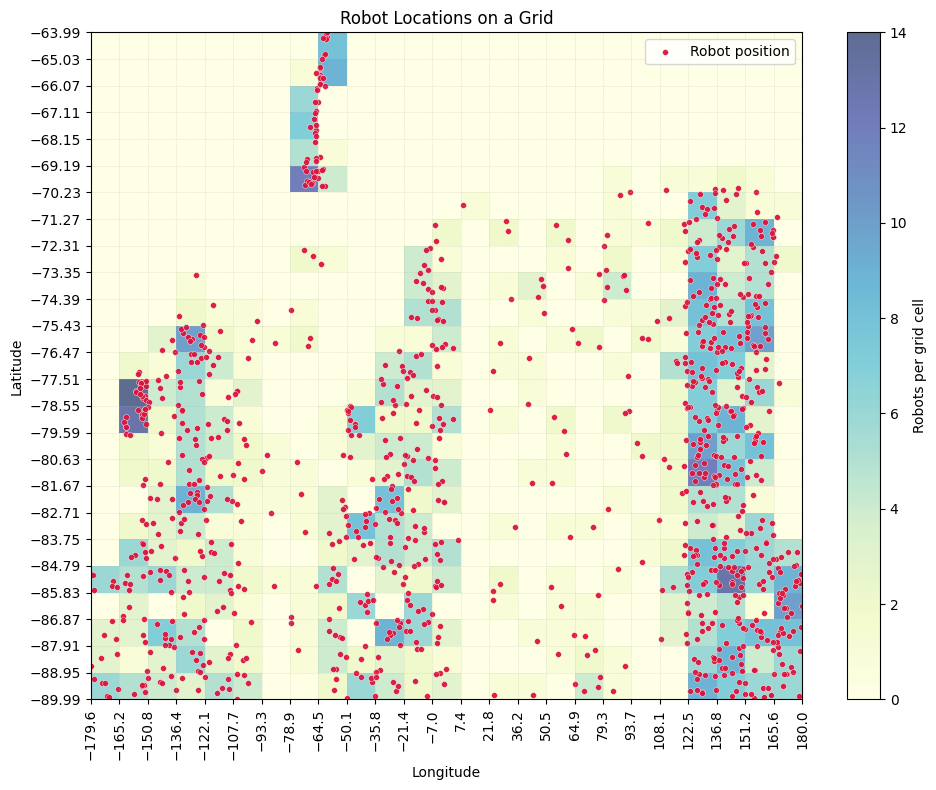

In [15]:
print(f'Number of robots: {len(robots)}')
print(f'Longitude range: {robots.longitude.min():.3f} to {robots.longitude.max():.3f}')
print(f'Latitude range: {robots.latitude.min():.3f} to {robots.latitude.max():.3f}')
print(f'Robot range: {robots["range"].min():.3f} to {robots["range"].max():.3f}')

grid_size = 25
lon_edges = np.linspace(robots['longitude'].min(), robots['longitude'].max(), grid_size + 1)
lat_edges = np.linspace(robots['latitude'].min(), robots['latitude'].max(), grid_size + 1)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.hist2d(
    robots['longitude'],
    robots['latitude'],
    bins=[lon_edges, lat_edges],
    cmap='YlGnBu',
    alpha=0.65
)
ax.scatter(
    robots['longitude'],
    robots['latitude'],
    s=18,
    c='crimson',
    edgecolors='white',
    linewidths=0.3,
    marker='o',
    alpha=0.95,
    label='Robot position'
)
plt.colorbar(heatmap[3], ax=ax, label='Robots per grid cell')
ax.set_title('Robot Locations on a Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks(lon_edges)
ax.set_yticks(lat_edges)
ax.tick_params(axis='x', labelrotation=90)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [16]:
# Random sample of robots

robots_subset = robots.sample(n=100, random_state=1).reset_index(drop=True).copy()

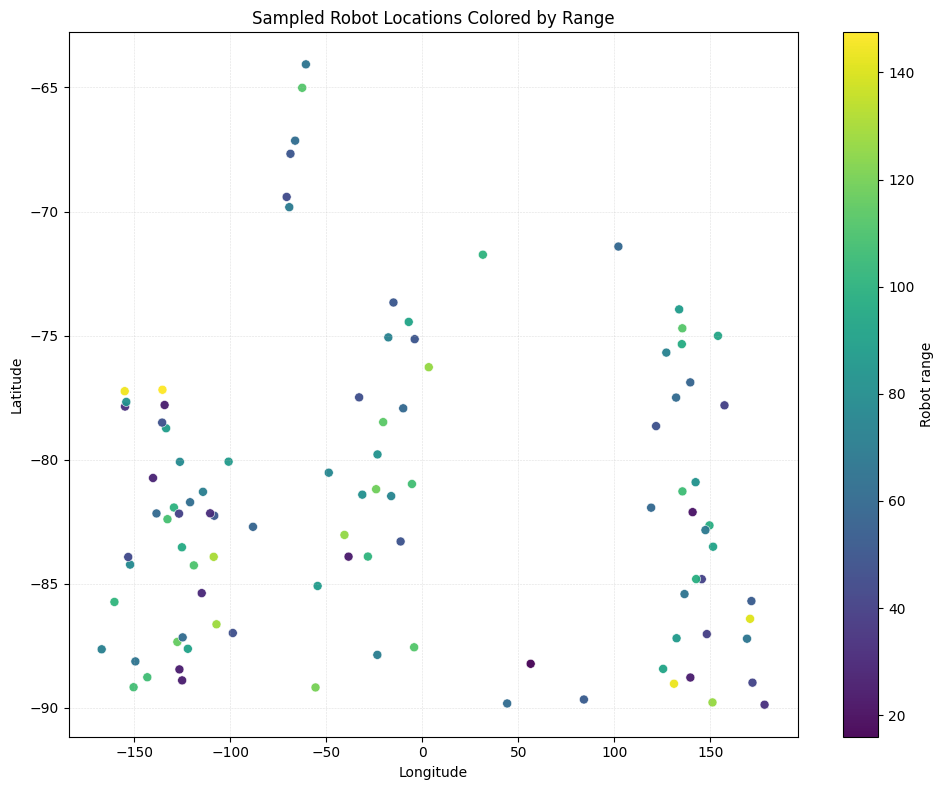

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    robots_subset['longitude'],
    robots_subset['latitude'],
    c=robots_subset['range'],
    cmap='viridis',
    s=42,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.95
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Robot range')
ax.set_title('Sampled Robot Locations Colored by Range')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.show()


### Model

In [18]:
# Model parameters from the assignment.
planning_days = 365 # run model for a year to account for annual costs
m = 8
q = 2
c_b = 5000
c_h = 1000
c_m = 500
c_c = 0.42
lambda_ = 0.012
r_min = 10
r_max = 175


#### Location

In [19]:
### Initialise with weighted k-means clustering to find central locations for stations

coords = robots_subset[["longitude", "latitude"]].to_numpy() # coordinates for clustering
weights = 1.0 / np.maximum(robots_subset["range"].to_numpy(), 1e-6) # weight by inverse of range to prioritize closer robots

# k = number of stations to try for run
k_values = [50]
# k_values = range(2, 7)

stations_by_k = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(coords, sample_weight=weights)

    stations = pd.DataFrame(
        km.cluster_centers_,
        columns=["longitude", "latitude"]
    )
    stations["station_id"] = range(k)
    stations["k"] = k
    stations = stations[["k", "station_id", "longitude", "latitude"]]

    stations_by_k[k] = stations

    print(f"k = {k}: created {len(stations)} initial stations")

display(stations_by_k[k_values[0]])


k = 50: created 50 initial stations


,k,station_id,longitude,latitude
0,50,0,-30.001175,-82.519951
1,50,1,133.382433,-78.869919
2,50,2,-125.514752,-88.259679
3,50,3,56.426577,-88.229542
4,50,4,-68.900108,-68.510843
5,50,5,171.025705,-87.340887
6,50,6,-167.074043,-87.645797
7,50,7,-5.085203,-74.902389
8,50,8,-88.241789,-82.708744
9,50,9,147.780424,-83.731384


#### Allocation

Function allocates each robot to one candidate station, subject to the capacity constraints of the stations. 


1) Compute maximum robot capacity per station:
m * q


2) For every robot-station pair:
 - compute distance
 - check whether the robot can reach the station
 - compute charging cost
 - compute transport penalty if needed
 - compute total assignment cost

3) Store all robot-station assignment possibilities in one table.

4) Sort those possibilities by cheapest assignment cost.

5) Greedily assign robots:
 - if robot already assigned, skip
 - if station is full, skip
 - otherwise assign robot to that station

Outputs:
 - assignments_df: which robot is assigned to which station
 - station_load: number of assigned robots at each station

In [20]:
def allocation_step(robots_subset, stations, planning_days, m, q, c_c, c_h, r_max):
    
    station_capacity = m * q # max number of robots a station can serve
    assignment_options = [] # list to store all possible robot-station assignment options

    for _, robot in robots_subset.iterrows(): # loop over every robot
        i = int(robot["robot_id"]) # robot ID
        r_i = float(robot["range"]) # robot's range
        robot_lon = float(robot["longitude"]) # robot's longitude
        robot_lat = float(robot["latitude"]) # robot's latitude

        for _, station in stations.iterrows(): # loop over every station 
            j = int(station["station_id"]) # station ID
            station_lon = float(station["longitude"]) # station longitude
            station_lat = float(station["latitude"]) # station latitude

            # robot-station euclidean distance
            d_ij = np.sqrt(
                (robot_lon - station_lon) ** 2 +
                (robot_lat - station_lat) ** 2
            )

            # binary variable indicating if robot i is unreachable from station j
            unreachable = int(d_ij > r_i)

            # Charging cost:
            # reachable   -> c_c * (r_max - r_i + d_ij)
            # unreachable -> c_c * (r_max - r_i)
            charging_cost = planning_days * c_c * (
                (r_max - r_i + d_ij) * (1 - unreachable)
                + (r_max - r_i) * unreachable
            )

            # Transport penalty if unreachable
            transport_cost = planning_days * c_h * unreachable

            total_cost = charging_cost + transport_cost

            assignment_options.append({
                "robot_id": i,
                "station_id": j,
                "distance": d_ij,
                "unreachable": unreachable,
                "assign_cost": total_cost
            })



    # Sort all assignment options by cost (lowest first)
    assignment_options_df = pd.DataFrame(assignment_options).sort_values(
        by="assign_cost"
    ).reset_index(drop=True)

    assigned_robots = set() #set of asigned robots
    station_load = {j: 0 for j in stations["station_id"]} # number of robots assigned to station j 
    assignments = [] # list to store assignments


    # Greedy assignment over all robot-station pairs, cheapest first
    for _, row in assignment_options_df.iterrows(): # loop over all assignment options sorted by cost
        i = int(row["robot_id"]) # robot ID
        j = int(row["station_id"]) # station ID

        # skip if robot is already assigned
        if i in assigned_robots: 
            continue

        # skip if station is at capacity
        if station_load[j] >= station_capacity:
            continue

        # accept assignment 
        assignments.append({
            "robot_id": i,
            "station_id": j,
            "distance": float(row["distance"]),
            "unreachable": int(row["unreachable"]),
            "assign_cost": float(row["assign_cost"])
        })

        assigned_robots.add(i) # robot i has now been assigned 
        station_load[j] += 1 # station j now has one more assigned robot 

    assignments_df = pd.DataFrame(assignments)

    if len(assignments_df) != len(robots_subset):
        raise RuntimeError(
            f"Only assigned {len(assignments_df)} of {len(robots_subset)} robots. Increase k or change the construction step."
        )

    return assignments_df, station_load


#### Location Update

At this stage:
 - robot assignments are fixed
 - station locations are changed


 - if a station is currently serving a certain group of robots then it should move toward those robots with extra pull from robots with smaller ranges (to avoid rescue penalties)
 
So this step tries to improve the station layout while holding assignments fixed.

In [21]:
def location_update_step(robots_subset, stations, assignments_df):
    updated_stations = stations.copy()

    for j in updated_stations["station_id"]: # loop over every station j

        # extract robot ids of assigned robots for station j
        assigned_robot_ids = assignments_df.loc[
            assignments_df["station_id"] == j, "robot_id"
        ].tolist()

        # skip if station has no assigned robots
        if len(assigned_robot_ids) == 0:
            continue

        # create dataframe of only robots assigned to station j
        assigned_robots_df = robots_subset[
            robots_subset["robot_id"].isin(assigned_robot_ids)
        ].copy()

        # weights inversely proportional to robot range
        weights = 1.0 / np.maximum(assigned_robots_df["range"].to_numpy(), 1e-6)

        # define new location of station j (weighted average of assigned robot locations)
        new_longitude = np.average(assigned_robots_df["longitude"], weights=weights)
        new_latitude = np.average(assigned_robots_df["latitude"], weights=weights)

        updated_stations.loc[
            updated_stations["station_id"] == j, "longitude"
        ] = new_longitude

        updated_stations.loc[
            updated_stations["station_id"] == j, "latitude"
        ] = new_latitude

    return updated_stations


#### Evaluation

Function computes charger counts and total annual cost for the current solution.

1) Compute station loads:
Count how many robots are assigned to each station.

2) Compute chargers needed:
For each station:
z_j = âŒˆrobots assigned / q âŒ‰.
This is the minimum number of chargers required.

3) Check feasibility:
Verify: z_j â‰¤ m
for every station.
If any station needs more than m chargers, the current solution is infeasible.

4) Recompute assignment costs:
Because the station locations have just changed, distances must be recomputed.
For every assigned robot-station pair:
 - recompute d_ij
 - determine if unreachable
 - compute charging cost
 - compute transport cost
 - compute total assignment cost
 - E. Compute total annual cost

Total cost = station build cost + charger maintenance cost + charging cost + transport cost

In [22]:
def evaluation_step(robots_subset, updated_stations, assignments_df, planning_days, q, m, c_b, c_m, c_c, c_h, r_max):

    # count number of robots assigned to each station
    station_loads_df = (
        assignments_df.groupby("station_id")
        .size()
        .reset_index(name="robots_assigned")
    )

    solution_stations = updated_stations.merge(
        station_loads_df,
        on="station_id",
        how="left"
    )

    # fill nan values
    solution_stations["robots_assigned"] = solution_stations["robots_assigned"].fillna(0).astype(int)

    # chargers needed at each station = ceil(robots_assigned / q)
    solution_stations["chargers"] = np.ceil(solution_stations["robots_assigned"] / q).astype(int)
    solution_stations["feasible_station"] = solution_stations["chargers"] <= m # check feasability

    all_robots_assigned = len(assignments_df) == len(robots_subset)
    solution_feasible = solution_stations["feasible_station"].all() and all_robots_assigned


    assignment_cost_records = [] # list to store updated assignment costs 

    # calculate new assignment costs based on upated station locations
    for _, row in assignments_df.iterrows():
        i = int(row["robot_id"])
        j = int(row["station_id"])

        robot = robots_subset[robots_subset["robot_id"] == i].iloc[0]
        station_row = solution_stations[solution_stations["station_id"] == j].iloc[0]

        r_i = float(robot["range"])

        d_ij = np.sqrt(
            (robot["longitude"] - station_row["longitude"]) ** 2 +
            (robot["latitude"] - station_row["latitude"]) ** 2
        )

        unreachable = int(d_ij > r_i)

        charging_cost = planning_days * c_c * (
            (r_max - r_i + d_ij) * (1 - unreachable)
            + (r_max - r_i) * unreachable
        )

        transport_cost = planning_days * c_h * unreachable
        total_cost = charging_cost + transport_cost

        assignment_cost_records.append({
            "robot_id": i,
            "station_id": j,
            "distance": d_ij,
            "unreachable": unreachable,
            "charging_cost": charging_cost,
            "transport_cost": transport_cost,
            "assign_cost": total_cost
        })

    solution_assignments = pd.DataFrame(assignment_cost_records)

    num_open_stations = (solution_stations["robots_assigned"] > 0).sum() # number of stations used
    fixed_cost = num_open_stations * c_b + solution_stations["chargers"].sum() * c_m # fixed costs 
    charging_cost_total = solution_assignments["charging_cost"].sum() # total charging costs
    transport_cost_total = solution_assignments["transport_cost"].sum() # total transport costs 
    total_solution_cost = fixed_cost + charging_cost_total + transport_cost_total # total cost of solution 

    return solution_stations, solution_assignments, total_solution_cost, solution_feasible


#### RUN HEURISTIC

This function runs the previous three steps: Allocation, Location Update, Evaluation   until convergence or a time-limit is reached

In [23]:
def run_alternating_heuristic(
    robots_subset,
    initial_stations,
    planning_days,
    m,
    q,
    c_b,
    c_m,
    c_c,
    c_h,
    r_max,
    max_iter=150,
    tolerance=1e-4,
    verbose=True
):
    
    stations_current = initial_stations.copy()
    cost_history = [] # to track cost over iterations for convergence
    patience = 3
    small_improvement_count = 0

    for iteration in range(1, max_iter + 1):
        # Step: Allocation
        assignments_df, station_load = allocation_step(
            robots_subset, stations_current, planning_days, m, q, c_c, c_h, r_max
        )

        # Step: Location Update
        updated_stations = location_update_step(
            robots_subset, stations_current, assignments_df
        )

        # Step: Evaluation
        solution_stations, solution_assignments, total_solution_cost, solution_feasible = evaluation_step(
            robots_subset, updated_stations, assignments_df,
            planning_days, q, m, c_b, c_m, c_c, c_h, r_max
        )

        cost_history.append(total_solution_cost) # track cost

    
        if verbose:
            print(
                f"Iteration {iteration}: "
                f"cost = {total_solution_cost:,.2f}, "
                f"open stations = {(solution_stations['robots_assigned'] > 0).sum()}, "
                f"chargers = {solution_stations['chargers'].sum()}, "
                f"feasible = {solution_feasible}"
            )

        # Convergence check
        if iteration > 1:
            improvement = cost_history[-2] - cost_history[-1]

            if improvement >= 0 and improvement < tolerance:
                small_improvement_count += 1
            else:
                small_improvement_count = 0

            if small_improvement_count >= patience:
                if verbose:
                    print(f"Converged after {iteration} iterations.")
                break
       

        stations_current = updated_stations.copy()

    return {
        "final_stations": solution_stations,
        "final_assignments": solution_assignments,
        "final_total_cost": total_solution_cost,
        "cost_history": cost_history,
        "feasible": solution_feasible
    }


#### Run the Heuristic

In [24]:
results_by_k = {}

for k in k_values:
    print(f"\nRunning alternating heuristic for k = {k}")
    
    results_by_k[k] = run_alternating_heuristic(
        robots_subset=robots_subset,
        initial_stations=stations_by_k[k],
        planning_days=planning_days,
        m=m,
        q=q,
        c_b=c_b,
        c_m=c_m,
        c_c=c_c,
        c_h=c_h,
        r_max=r_max,
        max_iter=30,
        tolerance=1e-4,
        verbose=False
    )

    print(f"k = {k}, final cost = {results_by_k[k]['final_total_cost']:,.2f}, feasible = {results_by_k[k]['feasible']}")



Running alternating heuristic for k = 50
k = 50, final cost = 1,826,376.19, feasible = True


### Results

In [25]:
summary_by_k = pd.DataFrame([
    {
        "k": k,
        "final_cost": results_by_k[k]["final_total_cost"],
        "feasible": results_by_k[k]["feasible"],
        "num_open_stations": int((results_by_k[k]["final_stations"]["robots_assigned"] > 0).sum()),
        "total_chargers": int(results_by_k[k]["final_stations"]["chargers"].sum()),
        "transport_robots": int(results_by_k[k]["final_assignments"]["unreachable"].sum())
    }
    for k in k_values
])

display(
    summary_by_k
    .sort_values("k")
    .style.format({"final_cost": "{:,.2f}"})
)


,k,final_cost,feasible,num_open_stations,total_chargers,transport_robots
0,50,"1,826,376.19",True,50,64,0


In [26]:
# Extract the best solution across all tested k values

best_k = summary_by_k.loc[summary_by_k["final_cost"].idxmin(), "k"]
best_result = results_by_k[best_k]

best_stations_df = best_result["final_stations"].copy()
best_assignments_df = best_result["final_assignments"].copy()
best_total_cost = best_result["final_total_cost"]
best_cost_history = best_result["cost_history"]

print("Best k:", best_k)
print("Best total cost:", best_total_cost)
print("Feasible:", best_result["feasible"])

display(best_stations_df)
display(best_assignments_df.head(20))


Best k: 50
Best total cost: 1826376.1851653198
Feasible: True


,k,station_id,longitude,latitude,robots_assigned,chargers,feasible_station
0,50,0,-30.001175,-82.519951,2,1,True
1,50,1,133.382433,-78.869919,2,1,True
2,50,2,-125.514752,-88.259679,5,3,True
3,50,3,56.426577,-88.229542,1,1,True
4,50,4,-68.900108,-68.510843,4,2,True
5,50,5,171.025705,-87.340887,4,2,True
6,50,6,-167.074043,-87.645797,1,1,True
7,50,7,-5.085203,-74.902389,2,1,True
8,50,8,-88.241789,-82.708744,1,1,True
9,50,9,147.780424,-83.731384,4,2,True


,robot_id,station_id,distance,unreachable,charging_cost,transport_cost,assign_cost
0,27,10,1.669997,0,4474.746340,0,4474.746340
1,205,12,0.578865,0,4755.339512,0,4755.339512
2,777,36,3.696168,0,5358.353877,0,5358.353877
3,719,5,0.969801,0,5363.792494,0,5363.792494
4,90,11,1.167150,0,7056.510610,0,7056.510610
5,453,49,0.000000,0,7515.156547,0,7515.156547
6,651,40,3.075703,0,7857.345959,0,7857.345959
7,383,19,1.930243,0,7868.887183,0,7868.887183
8,120,11,4.247545,0,7873.508086,0,7873.508086
9,258,34,2.445058,0,8828.955802,0,8828.955802


In [27]:
best_k = summary_by_k.loc[summary_by_k["final_cost"].idxmin(), "k"]
best_result = results_by_k[best_k]

best_stations_df = best_result["final_stations"].copy()
best_assignments_df = best_result["final_assignments"].copy()
best_total_cost = best_result["final_total_cost"]
best_cost_history = best_result["cost_history"]


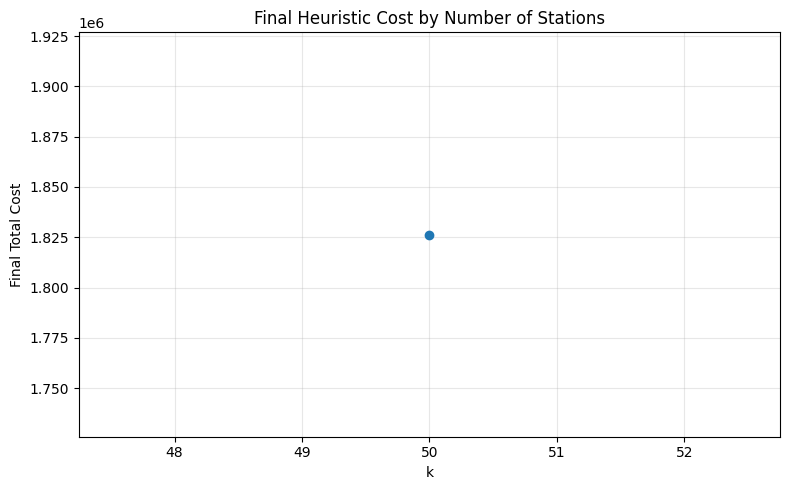

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary_by_k["k"], summary_by_k["final_cost"], marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Final Total Cost")
ax.set_title("Final Heuristic Cost by Number of Stations")
ax.grid(True, alpha=0.3)
fig.tight_layout()
#fig.savefig("Graphs/assignments_1b_b_station_comparison_100.png", dpi=300, bbox_inches="tight")
plt.show()


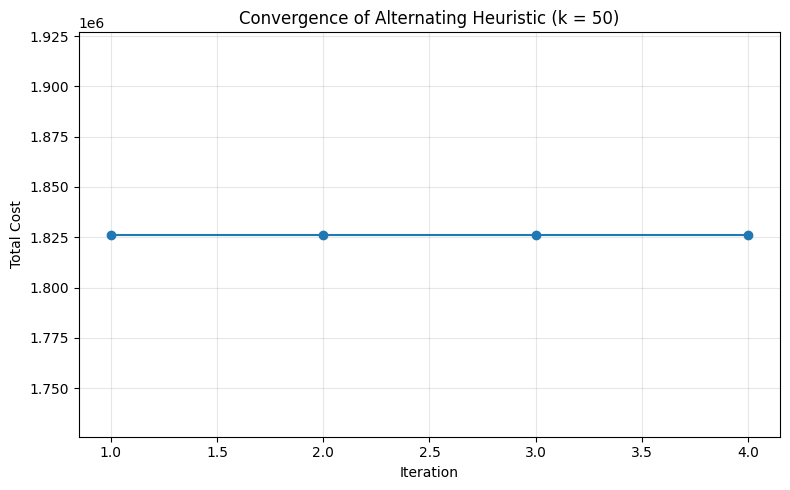

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(best_cost_history) + 1), best_cost_history, marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("Total Cost")
ax.set_title(f"Convergence of Alternating Heuristic (k = {best_k})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
#fig.savefig("Graphs/assignments_1b_b_convergence_100.png", dpi=300, bbox_inches="tight")
plt.show()


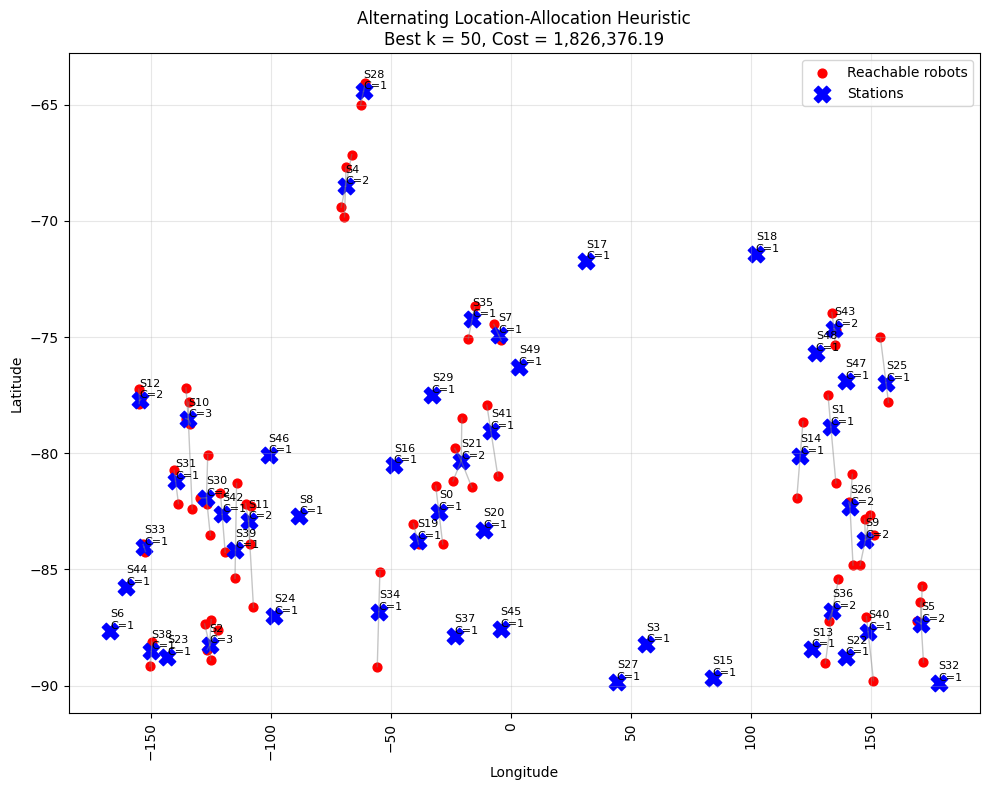

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

transport_robot_ids = set(
    best_assignments_df.loc[best_assignments_df["unreachable"] == 1, "robot_id"]
)

reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

# Plot robots
ax.scatter(
    reachable_robots["longitude"],
    reachable_robots["latitude"],
    c="red",
    s=40,
    label="Reachable robots"
)

if not transport_robots.empty:
    ax.scatter(
        transport_robots["longitude"],
        transport_robots["latitude"],
        c="darkorange",
        s=55,
        label="Transport-needed robots"
    )

# Plot final stations
ax.scatter(
    best_stations_df["longitude"],
    best_stations_df["latitude"],
    c="blue",
    s=140,
    marker="X",
    label="Stations"
)

# Label stations with ID and chargers
for _, row in best_stations_df.iterrows():
    ax.text(
        row["longitude"],
        row["latitude"],
        f"S{int(row['station_id'])}\nC={int(row['chargers'])}",
        fontsize=8,
        ha="left",
        va="bottom",
        color="black"
    )

# Plot assignment lines
for _, row in best_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = best_stations_df[best_stations_df["station_id"] == row["station_id"]].iloc[0]

    line_color = "darkorange" if row["unreachable"] == 1 else "gray"

    ax.plot(
        [robot["longitude"], station["longitude"]],
        [robot["latitude"], station["latitude"]],
        color=line_color,
        alpha=0.45,
        linewidth=1
    )

ax.set_title(f"Alternating Location-Allocation Heuristic\nBest k = {best_k}, Cost = {best_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


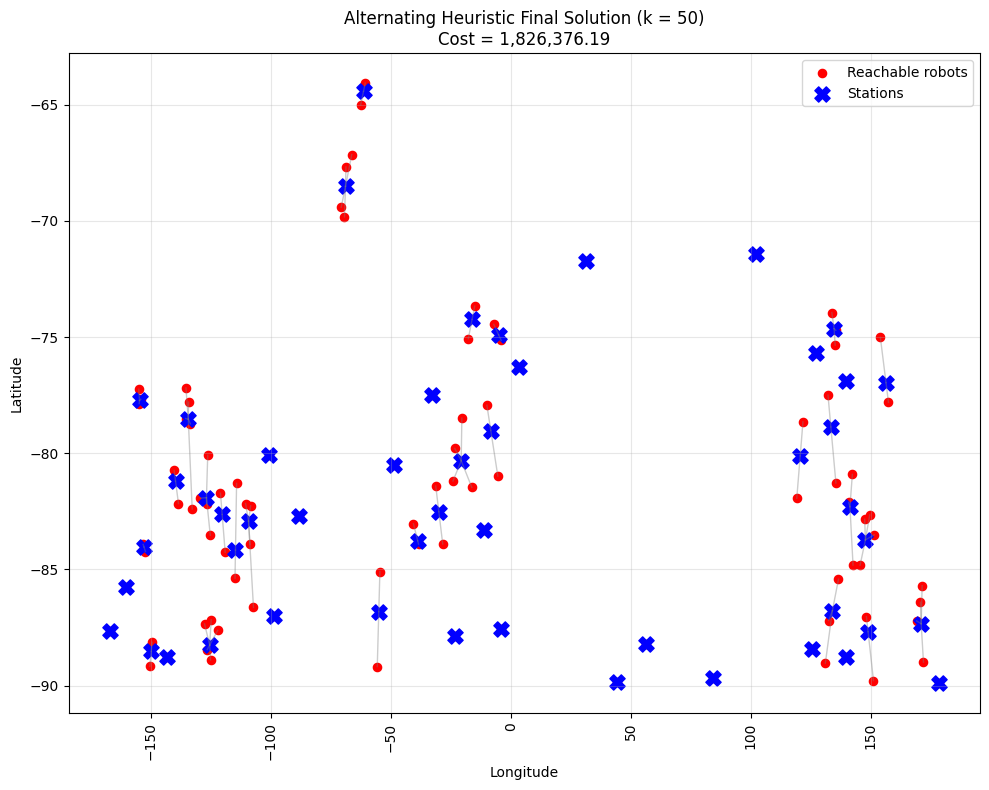

In [31]:
for k in summary_by_k["k"]:
    result = results_by_k[k]
    stations_df = result["final_stations"]
    assignments_df = result["final_assignments"]
    total_cost = result["final_total_cost"]

    fig, ax = plt.subplots(figsize=(10, 8))

    transport_robot_ids = set(
        assignments_df.loc[assignments_df["unreachable"] == 1, "robot_id"]
    )

    reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
    transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

    ax.scatter(reachable_robots["longitude"], reachable_robots["latitude"], c="red", s=35, label="Reachable robots")

    if not transport_robots.empty:
        ax.scatter(transport_robots["longitude"], transport_robots["latitude"], c="darkorange", s=50, label="Transport-needed robots")

    ax.scatter(stations_df["longitude"], stations_df["latitude"], c="blue", s=120, marker="X", label="Stations")

    for _, row in assignments_df.iterrows():
        robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
        station = stations_df[stations_df["station_id"] == row["station_id"]].iloc[0]
        line_color = "darkorange" if row["unreachable"] == 1 else "gray"
        ax.plot(
            [robot["longitude"], station["longitude"]],
            [robot["latitude"], station["latitude"]],
            color=line_color,
            alpha=0.4,
            linewidth=1
        )

    ax.set_title(f"Alternating Heuristic Final Solution (k = {k})\nCost = {total_cost:,.2f}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [32]:
# Final summary metrics for the best heuristic solution
final_num_robots = int(len(robots_subset))
final_num_stations = int((best_stations_df["robots_assigned"] > 0).sum())
final_num_chargers = int(best_stations_df["chargers"].sum())
 
final_buildings_cost = float(final_num_stations * c_b + final_num_chargers * c_m)
final_assignment_cost = float(best_assignments_df["charging_cost"].sum())
final_transport_cost = float(best_assignments_df["transport_cost"].sum())
final_total_cost = float(final_buildings_cost + final_assignment_cost + final_transport_cost)
final_robots_needing_transport = int(best_assignments_df["unreachable"].sum())
 
final_metrics = pd.DataFrame([
    {
        "# robots": final_num_robots,
        "# stations": final_num_stations,
        "# Chargers": final_num_chargers,
        "Total Cost": final_total_cost,
        "Assignment Cost": final_assignment_cost,
        "Buildings Cost": final_buildings_cost,
        "Transport Cost": final_transport_cost,
        "Robots Needing Transport": final_robots_needing_transport,
        "MIP gap": "N/A",
        "MIP gap %": "N/A"
    }
])

display(
    final_metrics.style.format({
        "# robots": "{:,.0f}",
        "# stations": "{:,.0f}",
        "# Chargers": "{:,.0f}",
        "Total Cost": "{:,.2f}",
        "Assignment Cost": "{:,.2f}",
        "Buildings Cost": "{:,.2f}",
        "Transport Cost": "{:,.2f}",
        "Robots Needing Transport": "{:,.0f}"
    })
)


,# robots,# stations,# Chargers,Total Cost,Assignment Cost,Buildings Cost,Transport Cost,Robots Needing Transport,MIP gap,MIP gap %
0,100,50,64,"1,826,376.19","1,544,376.19","282,000.00",0.00,0,N/A,N/A
